# How to read Seaborn plots

**Thời gian ước tính / Estimated time:** 25 phút

Đọc hình Seaborn = đọc hình Matplotlib **cộng thêm** vài lớp: màu nhóm (`hue`), dải quanh đường, vạch trên cột, hộp–râu, bản đồ nhiệt, nhiều ô.

Seaborn reading = Matplotlib reading **plus** `hue`, ribbons, error bars, box/violin, heatmaps, facets.

**Trước khi viết nhận xét, hỏi đủ 4 câu**

1. Trục đang đo **cái gì**? (từng điểm, trung bình, số đếm, mật độ…)
2. Có **nhóm màu / ô facet** không? Mỗi nhóm đọc riêng.
3. **Hướng hoặc thứ hạng:** tăng, giảm, ai cao nhất, lệch trái/phải?
4. Hình **giấu gì**? (dải CI không phải min–max; box giấu nhiều đỉnh; n nhỏ)

Do not write the function name. Write answers to those four questions.


## Mục lục / Table of Contents

1. [Câu hỏi thêm: `hue`](#hue)
2. [Scatter](#scatter)
3. [Line + dải tin cậy](#line)
4. [Barplot vs countplot](#bar)
5. [Hist / KDE](#hist)
6. [Boxplot](#box)
7. [Violin](#violin)
8. [Heatmap](#heat)
9. [Facet (`relplot` / `catplot`)](#facet)
10. [Pairplot](#pair)
11. [Khung nhận xét](#khung)


Chạy cell dưới một lần. Dữ liệu **tự tạo** (không gắn lab).

Run once. Toy data only.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="deep")
np.random.seed(0)

n = 240
df = pd.DataFrame({
    "x": np.r_[np.random.normal(2, 0.9, n // 2), np.random.normal(3.2, 0.9, n // 2)],
    "y": np.r_[
        1.2 * np.random.normal(2, 0.9, n // 2) + np.random.normal(0, 0.6, n // 2),
        0.4 * np.random.normal(3.2, 0.9, n // 2) + 2 + np.random.normal(0, 0.6, n // 2),
    ],
    "nhom": ["A"] * (n // 2) + ["B"] * (n // 2),
})
thang = np.arange(1, 13)
df_time = pd.DataFrame({
    "thang": np.tile(thang, 40),
    "nhom": np.repeat(["A", "B"], 20 * 12),
    "y": np.r_[
        np.tile(2 + 0.4 * thang, 20) + np.random.normal(0, 0.5, 20 * 12),
        np.tile(8 - 0.3 * thang, 20) + np.random.normal(0, 0.5, 20 * 12),
    ],
})
df_cat = pd.DataFrame({
    "nhom": np.repeat(["A", "B", "C"], 80),
    "y": np.r_[
        np.random.normal(5, 1.0, 80),
        np.random.normal(7, 1.2, 80),
        np.random.normal(4.5, 0.8, 80),
    ],
})
df.head()


,x,y,nhom
0,3.587647,2.130642,A
1,2.360141,1.973209,A
2,2.880864,2.815598,A
3,4.016804,2.282365,A
4,3.680802,2.056857,A


## 1. Câu hỏi thêm: `hue` <a id="hue"></a>

Với Matplotlib, câu gốc là: *X sang phải thì Y thế nào?*

`hue="tên_cột"` **tô màu theo nhóm**. Phải hỏi thêm: *màu này khác màu kia không?*

### Làm lần lượt

1. Tắt `hue` trong đầu: đám chấm/cột nhìn như **một** nhóm.
2. Bật `hue`: tách theo **chú thích màu** (legend).
3. Với **từng màu**, hỏi lại câu Matplotlib (hướng, đỉnh, thứ hạng).
4. So các màu: lệch lên/xuống, tách đám, hay chồng lên nhau?

| Bạn thấy | Viết |
|---|---|
| Hai màu thành **hai đám** | hai nhóm khác nhau |
| Hai màu **trộn một đám** | nhóm gần như không khác trên hai trục này |
| Legend có `hue` và `style` | `hue` = màu, `style` = hình marker — đừng gọi cả hai là “màu” |

Ví dụ: không `hue` có thể bảo “X và Y cùng chiều”. Có `hue` mới thấy nhóm B nằm cao hơn — kết luận khác hẳn.


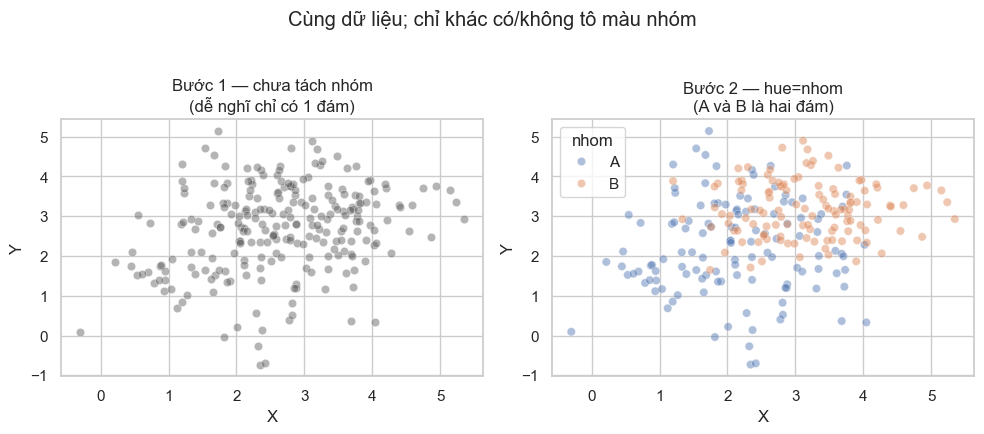

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))

sns.scatterplot(data=df, x="x", y="y", ax=axes[0], alpha=0.45, color="0.35")
axes[0].set_title("Bước 1 — chưa tách nhóm\n(dễ nghĩ chỉ có 1 đám)")
axes[0].set(xlabel="X", ylabel="Y")

sns.scatterplot(data=df, x="x", y="y", hue="nhom", ax=axes[1], alpha=0.45)
axes[1].set_title("Bước 2 — hue=nhom\n(A và B là hai đám)")
axes[1].set(xlabel="X", ylabel="Y")

fig.suptitle("Cùng dữ liệu; chỉ khác có/không tô màu nhóm", y=1.03)
fig.tight_layout()
plt.show()


**Đọc hai hình này chậm**

* **Trái:** mọi chấm một màu. Bạn chỉ nói được “có một đám, hơi cùng chiều”. **Không** biết có hai loại người/nhóm bên trong.
* **Phải:** xem **legend**. Màu 1 = nhóm A, màu 2 = nhóm B. Hai đám **tách**. Nếu viết nhận xét mà bỏ `hue`, bạn đã gộp A và B thành một — dễ sai.

**Câu mẫu:** “Khi chưa tách nhóm, chỉ thấy một mây. Sau `hue`, A và B tách; B nằm phía Y cao hơn.”

Left: one cloud. Right: two groups. Skipping `hue` pools them by mistake.


## 2. Scatter <a id="scatter"></a>

Câu gốc (như Matplotlib): *Khi X sang **phải** (lớn hơn), Y thế nào?*

* Y cũng lớn hơn → **cùng chiều**
* Y nhỏ hơn → **ngược chiều**
* Y loạn → **không đoán được**

`corr` gần +1 / −1 / 0 = chặt cùng chiều / chặt ngược / không có chiều. Chi tiết xem `w3_4_How-to-Read-Plots.ipynb`.

### Thêm `hue` — đừng gộp màu

1. Chỉ nhìn **một màu** (ví dụ chỉ A): X sang phải thì Y ra sao?
2. Lặp với màu kia.
3. So: nhóm nào **cao hơn** (tịnh tiến lên trục Y)? Độ dốc có giống nhau không?

Nếu đề hỏi “A khác B không”, **cấm** tính một `corr` chung cho mọi chấm.


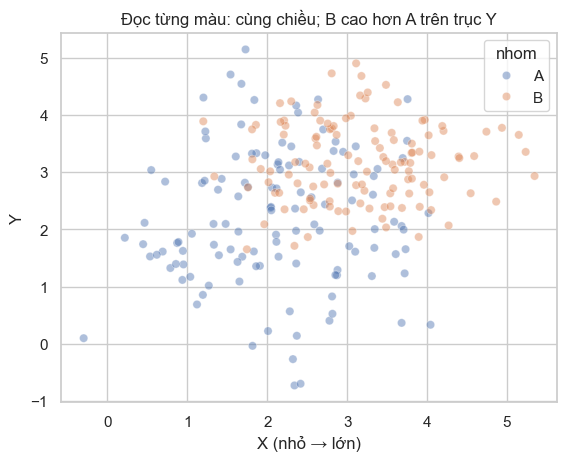

In [3]:
ax = sns.scatterplot(data=df, x="x", y="y", hue="nhom", alpha=0.45)
ax.set(title="Đọc từng màu: cùng chiều; B cao hơn A trên trục Y",
       xlabel="X (nhỏ → lớn)", ylabel="Y")
plt.show()


**Đọc từng bước**

1. Chỉ nhìn chấm **A**: X lớn hơn thì Y có xu hướng lớn hơn → A **cùng chiều**.
2. Chỉ nhìn chấm **B**: cũng cùng chiều.
3. So hai đám: đám B nằm **cao hơn** (cùng X, Y của B lớn hơn).
4. Viết: “Cả hai nhóm X–Y cùng chiều; B có Y cao hơn A. Không gộp hai nhóm thành một hệ số corr.”

**How to read:** one color at a time, then compare height and slope. Do not pool groups.


## 3. Line + dải tin cậy <a id="line"></a>

`sns.lineplot` **không** vẽ mọi điểm rồi nối. Mặc định nó làm 2 việc:

1. Tại mỗi giá trị X, lấy **trung bình** các Y → đó là **đường**.
2. Vẽ **dải mờ** quanh đường = **khoảng tin cậy** (thường 95%) cho cái trung bình đó.

### Dải mờ **không** phải

* không phải min–max
* không phải “toàn bộ dữ liệu nằm trong dải”
* không phải độ lệch chuẩn của từng người (trừ khi bạn đổi `errorbar="sd"`)

Nhiều điểm **nằm ngoài dải** vẫn bình thường. Dải chỉ nói: *ta chắc chắn về đường mean đến mức nào*.

| Nhìn | Viết |
|---|---|
| Đường lên / xuống | trung bình tăng / giảm |
| Dải **mỏng** | mean ước lượng chắc (n lớn hoặc ít nhiễu) |
| Dải **dày** | mean còn bất định |
| Hai dải **tách, ít chồng** | hai nhóm mean khác nhau khá rõ |
| Hai dải **chồng nhiều** | chênh mean chưa chắc, đừng khẳng định mạnh |


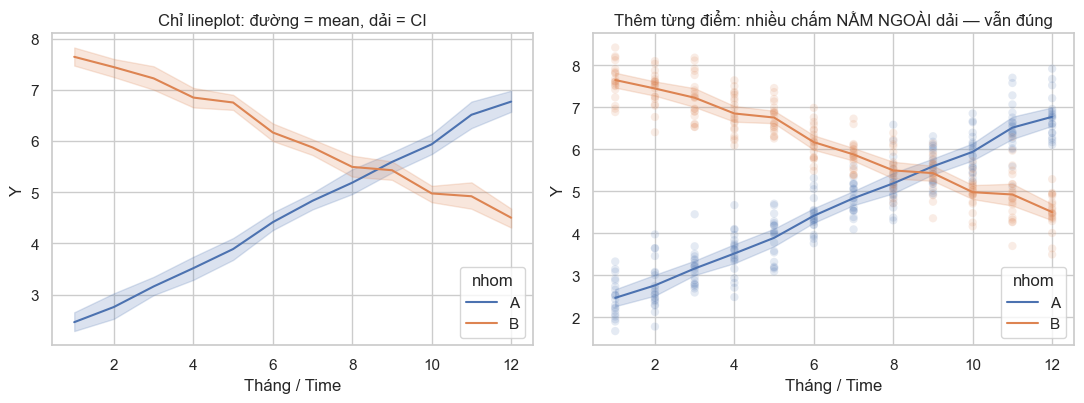

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

sns.lineplot(data=df_time, x="thang", y="y", hue="nhom", ax=axes[0])
axes[0].set(title="Chỉ lineplot: đường = mean, dải = CI",
            xlabel="Tháng / Time", ylabel="Y")

# Cùng lineplot, vẽ thêm từng điểm để thấy điểm LẸCH ra ngoài dải
sns.scatterplot(data=df_time, x="thang", y="y", hue="nhom",
                alpha=0.15, legend=False, ax=axes[1])
sns.lineplot(data=df_time, x="thang", y="y", hue="nhom", ax=axes[1])
axes[1].set(title="Thêm từng điểm: nhiều chấm NẰM NGOÀI dải — vẫn đúng",
            xlabel="Tháng / Time", ylabel="Y")

fig.tight_layout()
plt.show()


**Đọc chậm**

* **Đường A** đi lên, **đường B** đi xuống, chúng **cắt nhau**. Đó là câu chuyện của **trung bình**.
* **Dải**: chỗ mỏng = mean tin hơn; chỗ dày = mean lung lay hơn.
* **Hình phải:** chấm nhạt là **từng dòng**. Chúng rải rộng hơn dải. **Không** viết “mọi quan sát nằm trong dải 95%”.
* Muốn tắt dải: `errorbar=None`. Muốn vạch = độ lệch chuẩn: `errorbar="sd"`.

**Câu mẫu:** “Mean nhóm A tăng theo tháng, mean B giảm; dải hai nhóm tách dần nên hướng ngược nhau khá rõ. Các điểm thô vẫn phân tán ngoài dải.”

The ribbon is uncertainty of the **mean**. Raw points routinely fall outside it.


## 4. Barplot vs countplot <a id="bar"></a>

Hai hàm trông giống cột nhưng **số trên cột khác nhau**. Đọc **trục Y** trước.

| Hàm | Mỗi cột là | Cần cột `y`? |
|---|---|---|
| `countplot` | **đếm số dòng** trong nhóm | không |
| `barplot` | mặc định **trung bình** của `y` | có |
| `barplot(..., estimator="sum")` | **tổng** `y` | có |

### Vạch trên `barplot`

Vạch (error bar) = độ bất định hoặc độ phân tán của số trên cột (`sd`, `ci`, …), **không** phải số đếm.

### Thứ tự đọc

1. Đây là count hay mean hay sum? (đọc title / ylabel)
2. Cột nào cao nhất / thấp nhất?
3. Vạch có chồng nhau không? Chồng nhiều → chênh mean chưa chắc.
4. Cột cao nhưng **ít dòng** (xem `countplot` cạnh đó) → kết luận yếu.


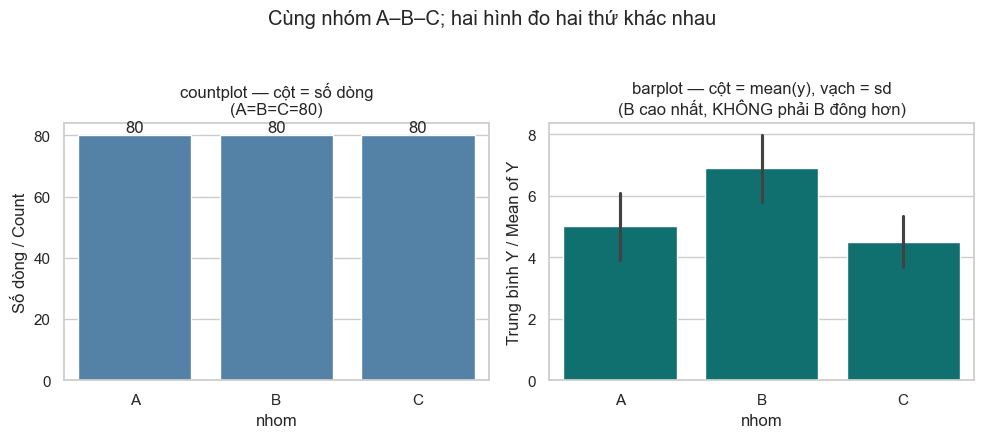

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))

sns.countplot(data=df_cat, x="nhom", ax=axes[0], color="steelblue")
axes[0].set(title="countplot — cột = số dòng\n(A=B=C=80)", ylabel="Số dòng / Count")
for c in axes[0].containers:
    axes[0].bar_label(c)

sns.barplot(data=df_cat, x="nhom", y="y", estimator="mean", errorbar="sd",
            ax=axes[1], color="teal")
axes[1].set(title="barplot — cột = mean(y), vạch = sd\n(B cao nhất, KHÔNG phải B đông hơn)",
            ylabel="Trung bình Y / Mean of Y")

fig.suptitle("Cùng nhóm A–B–C; hai hình đo hai thứ khác nhau", y=1.04)
fig.tight_layout()
plt.show()


**Đọc**

* **Trái:** ba cột **bằng nhau** → mỗi nhóm 80 dòng. Không ai “đông” hơn.
* **Phải:** cột **B cao nhất** = trung bình Y của B lớn nhất. Vạch là **sd**, càng dài nhóm càng phân tán.
* Sai điển hình: nhìn phải rồi nói “B có nhiều quan sát nhất”. Số dòng nằm ở hình **trái**.

**Câu mẫu:** “Số dòng ba nhóm bằng nhau. Mean Y cao nhất ở B; vạch sd của B cũng hơi dài hơn nên B vừa cao vừa phân tán hơn.”

Left = how many rows. Right = how large the mean is. Never mix them.


## 5. Hist / KDE <a id="hist"></a>

Câu gốc (Matplotlib): tìm **đỉnh**, so **hai đuôi** (cân / lệch trái / lệch phải). Mean bị kéo về đuôi dài.

`hue` = vẽ **nhiều** hist/KDE trên một trục. Đọc **từng màu**, rồi so vị trí đỉnh.

### Hist vs KDE

* **Hist:** cột = tần suất (hoặc mật độ) trong từng khoảng.
* **KDE:** đường mượt ước lượng mật độ; **không có cột**. So **chỗ phình** (đỉnh) và **đuôi**, đừng so “đường nào cao pixel hơn” nếu chưa cùng `stat`.

### `common_norm`

* `True` (đôi khi mặc định): nhóm đông **tô nhiều diện tích hơn** — dễ tưởng nhóm đó “cao hơn” chỉ vì n lớn.
* `False`: mỗi nhóm tự chuẩn hóa — so **hình dạng**, công bằng hơn khi n lệch.

KDE: diện tích mỗi đường ≈ 1 khi tách nhóm đúng cách; nhận xét **đỉnh lệch trái/phải**, **hẹp/rộng** (hẹp = ít phân tán).


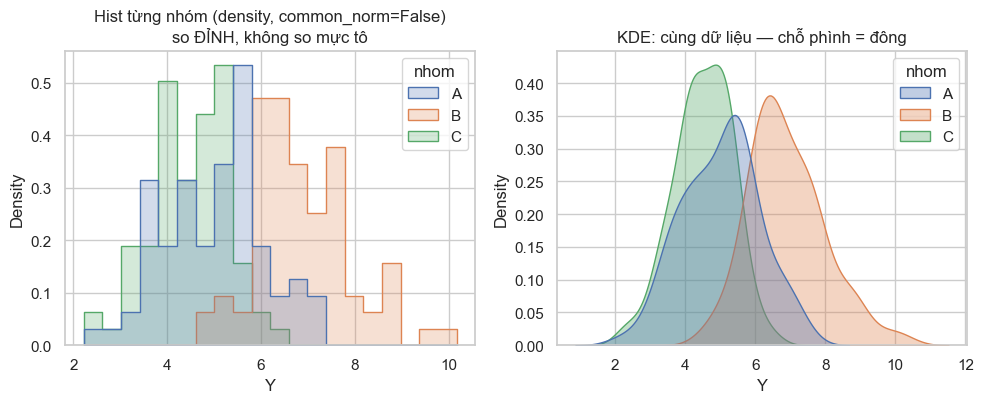

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))

sns.histplot(data=df_cat, x="y", hue="nhom", bins=20, element="step",
             stat="density", common_norm=False, ax=axes[0])
axes[0].set(title="Hist từng nhóm (density, common_norm=False)\nso ĐỈNH, không so mực tô",
            xlabel="Y")

sns.kdeplot(data=df_cat, x="y", hue="nhom", fill=True, alpha=0.35, ax=axes[1],
            common_norm=False)
axes[1].set(title="KDE: cùng dữ liệu — chỗ phình = đông",
            xlabel="Y")

fig.tight_layout()
plt.show()


**Đọc**

1. Tìm đỉnh từng màu trên trục X (giá trị Y).
2. Đỉnh **B** nằm **bên phải** hơn → B có nhiều giá trị lớn hơn.
3. Đỉnh A và C gần nhau; đường C **hẹp hơn** → C ít phân tán hơn.
4. Đuôi: nhìn màu nào kéo xa hơn về một phía.

**Câu mẫu:** “B lệch về giá trị lớn hơn A và C. C tập trung hẹp quanh đỉnh. Đang so mật độ từng nhóm (`common_norm=False`), không so ‘nhóm nào tô đậm hơn’.”

Peak position = typical value. Width = spread. Tail = skew.


## 6. Boxplot <a id="box"></a>

Boxplot tóm một nhóm thành **vài mốc**, đọc **từ trong ra ngoài**:

```
        o     ← chấm: ngoại lai (theo quy tắc hộp, không phải “sai số”)
        |
       râu    ← râu trên
        |
   +----+----+  ← cạnh trên hộp = Q3 (75%)
   |         |
   |----|    |  ← vạch giữa hộp = TRUNG VỊ (median), không phải mean
   |         |
   +----+----+  ← cạnh dưới hộp = Q1 (25%)
        |
       râu    ← râu dưới
```

| Bộ phận | Ý nghĩa |
|---|---|
| Vạch trong hộp | **trung vị**: nửa số điểm dưới, nửa trên |
| Chiều cao hộp | 50% giữa (IQR). Hộp **cao** = phân tán mạnh hơn |
| Râu | phần còn lại, thường cắt ở 1.5×IQR |
| Chấm | điểm ngoài râu = ngoại lai *theo boxplot* |
| `hue` | hai hộp kề nhau tại một `x` = nhóm phụ |

**Giấu gì:** nhiều đỉnh (hai cụm trong một nhóm) — hộp vẫn một thùng. Muốn thấy hình dạng: hist / KDE / violin.


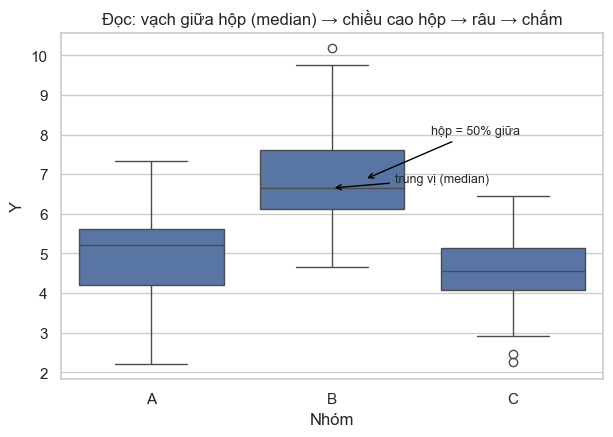

In [7]:
fig, ax = plt.subplots(figsize=(7, 4.5))
sns.boxplot(data=df_cat, x="nhom", y="y", ax=ax)
ax.set(title="Đọc: vạch giữa hộp (median) → chiều cao hộp → râu → chấm",
       xlabel="Nhóm", ylabel="Y")

# Ghi chú trên nhóm B (median cao nhất) — vị trí x=1
q1, med, q3 = df_cat.loc[df_cat["nhom"] == "B", "y"].quantile([0.25, 0.5, 0.75])
ax.annotate("trung vị (median)", xy=(1, med), xytext=(1.35, med + 0.15),
            arrowprops=dict(arrowstyle="->", color="black"), fontsize=9)
ax.annotate("hộp = 50% giữa", xy=(1.18, (q1 + q3) / 2), xytext=(1.55, q3 + 0.4),
            arrowprops=dict(arrowstyle="->", color="black"), fontsize=9)
plt.show()


**Đọc**

1. So **vạch giữa hộp**: B cao nhất → median B lớn nhất.
2. So **chiều cao hộp**: hộp nào cao hơn thì 50% giữa phân tán hơn.
3. **Chấm** trên/dưới râu: có ngoại lai không? Nhiều chấm = đuôi nặng, đừng chỉ nhìn max.
4. Viết median + phân tán + ngoại lai. **Không** nói “trung bình” trừ khi bạn biết box đang vẽ mean (mặc định là median).

**Câu mẫu:** “Median B cao hơn A và C. Hộp B hơi cao hơn nên phân tán 50% giữa cũng lớn hơn. Có vài điểm ngoài râu phía trên B.”

Median, then box height, then outliers. Do not call the middle line the mean.


## 7. Violin <a id="violin"></a>

Violin = mật độ (KDE) **soi gương** hai bên, thường kèm vạch tứ phân vị / box bên trong.

### Đọc bề rộng, không chỉ “cây đàn”

* Chỗ **phình (rộng)** trên trục Y = **nhiều** quan sát ở mức Y đó (đông).
* Chỗ **eo (hẹp)** = ít quan sát.
* **Đỉnh phình** cao trên trục Y = nhóm có nhiều giá trị lớn (tương tự đỉnh hist lệch phải).
* Vạch trong (`inner="quartile"` hoặc box) = median / Q1 / Q3 — đọc như boxplot.

`split=True` + `hue`: **nửa trái / nửa phải** của cùng một violin = hai nhóm phụ, dễ so hình dạng tại cùng `x`.

Violin shows **shape** that a box hides. Width = how many points live at that y.


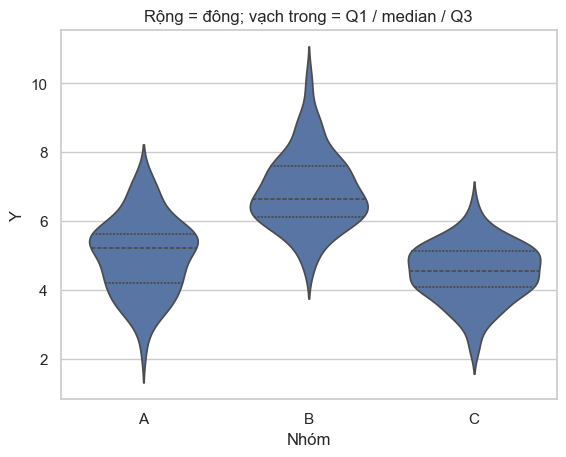

In [8]:
sns.violinplot(data=df_cat, x="nhom", y="y", inner="quartile")
plt.title("Rộng = đông; vạch trong = Q1 / median / Q3")
plt.xlabel("Nhóm")
plt.ylabel("Y")
plt.show()


**Đọc**

1. Nhìn **chỗ phình** của B: nằm **cao hơn** A và C → B đông ở mức Y lớn hơn.
2. Nhìn **vạch giữa** trong đàn: đó là median, đối chiếu với boxplot.
3. Violin **mảnh** = ít phân tán; **bè** = phân tán mạnh hoặc nhiều giá trị trải dài.
4. Kết hợp: B vừa median cao hơn vừa phân bố lệch lên trên.

**Câu mẫu:** “Violin B phình ở Y cao hơn; tứ phân vị trong đàn khớp hướng đó. A và C hẹp hơn, tập trung thấp hơn.”

Width = crowd at that y. Inner lines = quartiles. Shape is the extra information vs a box.


## 8. Heatmap <a id="heat"></a>

Mỗi ô một số; **màu** mã hóa số đó. Không có “chiều cao cột”.

### Thứ tự đọc

1. Đọc **thanh màu (colorbar)**: màu nào = số lớn, màu nào = số nhỏ / âm.
2. Đọc **một ô:** hàng nào + cột nào + số (nếu `annot=True`).
3. Rồi mới so các ô: ô nào nóng nhất / lạnh nhất; có dải theo cả hàng hoặc cả cột không.

### Heatmap tương quan (`corr`)

* Ô `(i, i)` trên **đường chéo** luôn ≈ **1** (biến tự so với chính nó) — **không** phải phát hiện mới.
* Ô `(x, y)` = `corr(x, y)`: gần +1 cùng chiều chặt; gần −1 ngược chiều chặt; gần 0 không có chiều.
* Ma trận đối xứng: `(x, y)` = `(y, x)` — chỉ cần đọc một nửa.

### Heatmap bảng (tháng × năm, cửa hàng × sản phẩm…)

Tìm ô cực trị, rồi xem **hàng** (một tháng mọi năm) hoặc **cột** (một năm mọi tháng) có nóng dần không.


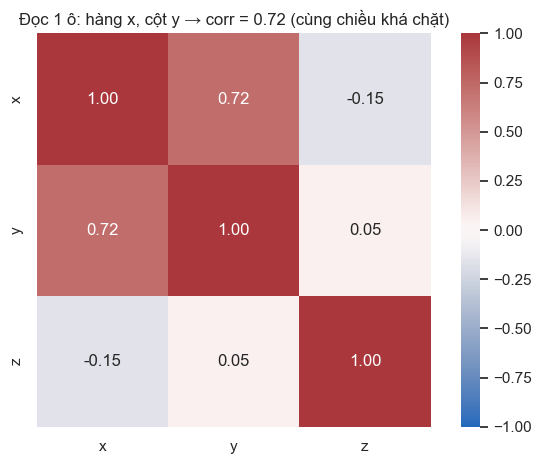

In [9]:
mat = pd.DataFrame(
    [[1.00, 0.72, -0.15],
     [0.72, 1.00, 0.05],
     [-0.15, 0.05, 1.00]],
    index=["x", "y", "z"],
    columns=["x", "y", "z"],
)
ax = sns.heatmap(mat, annot=True, fmt=".2f", cmap="vlag", center=0, square=True,
                 vmin=-1, vmax=1)
ax.set_title("Đọc 1 ô: hàng x, cột y → corr = 0.72 (cùng chiều khá chặt)")
plt.tight_layout()
plt.show()


**Đọc từng ô**

* `x` với `x` = 1.00 → đường chéo, bỏ qua.
* `x` với `y` = **0.72** → cùng chiều, khá chặt (chấm scatter sẽ bám đường hơn hình “corr ≈ 0”).
* `x` với `z` = **−0.15** → gần 0, hơi âm — practically “gần như không liên quan”.
* `y` với `z` = 0.05 → gần 0.

**Câu mẫu:** “Cặp đáng chú ý là x–y (0.72). Các cặp với z gần 0. Không nhận xét đường chéo.”

Read the colorbar, then one off-diagonal cell. Ignore the 1.00 diagonal.


## 9. Facet (`relplot` / `catplot`) <a id="facet"></a>

`col="nhom"` (hoặc `row`) = **cắt dữ liệu** thành nhiều ô, mỗi ô một giá trị nhóm. Cùng loại hình, khác lát dữ liệu.

### Đọc như đọc truyện tranh

1. Đọc **title từng ô** (ô này là nhóm nào).
2. Trong ô, dùng đúng checklist loại hình (scatter / box / …).
3. **So các ô với nhau:** độ dốc, thứ hạng, lệch, ngoại lai — cái gì **giữ nguyên**, cái gì **đổi** khi sang nhóm khác?

`relplot` / `catplot` tạo **figure mới**, không nhét vào `ax=` có sẵn. Muốn 1 figure nhiều loại hình: `sns.scatterplot(..., ax=...)` trên `plt.subplots`.


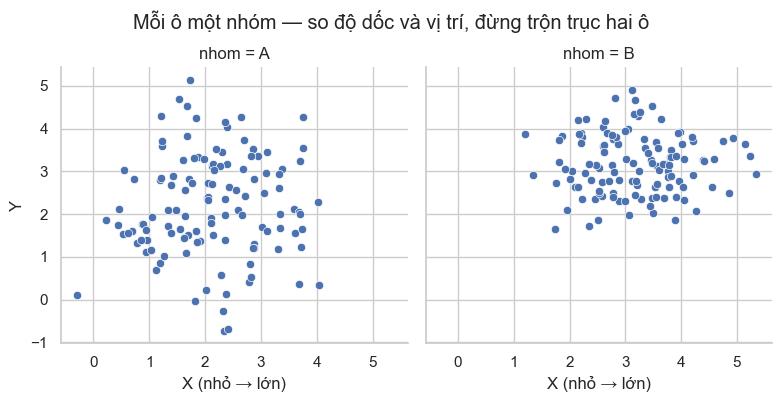

In [10]:
g = sns.relplot(
    data=df, kind="scatter", x="x", y="y",
    col="nhom", height=3.8, aspect=1.05,
)
g.set_axis_labels("X (nhỏ → lớn)", "Y")
g.fig.suptitle("Mỗi ô một nhóm — so độ dốc và vị trí, đừng trộn trục hai ô", y=1.05)
plt.show()


**Đọc**

* Ô trái = chỉ nhóm A. Ô phải = chỉ nhóm B. **Không** còn hai màu trong một ô.
* Trong từng ô: X sang phải thì Y thế nào? (cùng chiều / ngược / loạn)
* So hai ô: B có đám **cao hơn** A không? Độ dốc có khác không?
* Một ô có đám phụ / ngoại lai mà ô kia không có không?

**Câu mẫu:** “Cả hai ô X–Y cùng chiều. Ô B nằm cao hơn ô A trên trục Y. Không thấy đảo chiều khi đổi nhóm.”

One panel = one slice. Compare slope and location across panels.


## 10. Pairplot <a id="pair"></a>

Lưới mọi cặp biến số. **Đừng** nhận xét cả lưới một câu.

### Bản đồ lưới

* **Đường chéo** (ô `x`–`x`, `y`–`y`, …): phân phối **một** biến (hist/KDE) — đọc như hist: đỉnh, đuôi, lệch.
* **Ô ngoài chéo** (ô `x`–`y`): scatter hai biến — đọc như scatter: cùng chiều / ngược / loạn.
* `hue`: màu nhóm lặp lại trên **mọi** ô.
* `corner=True`: chỉ nửa dưới — đủ vì nửa trên là ảnh gương.

### Cách đọc một cặp

1. Chọn hai tên, ví dụ `x` và `y`.
2. Tìm ô giao `x` (một trục) với `y` (trục kia).
3. Viết nhận xét **chỉ cặp đó**, rồi mới sang cặp khác.


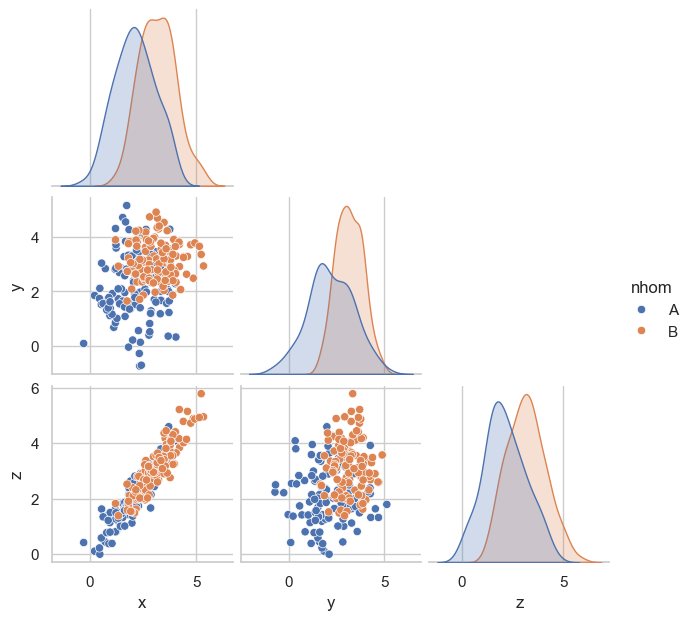

In [11]:
df_pair = df.copy()
df_pair["z"] = df_pair["x"] + np.random.normal(0, 0.4, len(df))
sns.pairplot(df_pair, vars=["x", "y", "z"], hue="nhom", corner=True, height=2.1)
plt.show()


**Đọc**

* Ô chéo `x`–`x`: hist/KDE của x — A và B có đỉnh khác nhau không?
* Ô `x`–`y`: scatter đã thấy ở mục 2 — cùng chiều, B cao hơn.
* Ô `x`–`z`: `z` gần như x cộng nhiễu → scatter rất chặt, corr cao (kiểm tra bằng mắt: chấm bám đường).

**Câu mẫu:** “Chéo: x của B lệch phải hơn A. Cặp x–y cùng chiều. Cặp x–z rất chặt vì z được tạo từ x.”

Diagonal = one-variable shape. Off-diagonal = one pair. One pair per sentence.


## 11. Khung nhận xét / Template <a id="khung"></a>

```
# 1. Hình này đang vẽ GÌ trên trục? (điểm / mean / count / mật độ / corr)
# 2. Hue hoặc facet: tôi đang nói nhóm nào? đã tách màu chưa?
# 3. Nhìn thấy: hướng (lên/xuống), thứ hạng (ai cao), lệch (đuôi nào), corr (chặt/lỏng)
# 4. Hình giấu gì: CI ≠ min-max; barplot ≠ count; box giấu nhiều đỉnh; n nhỏ
```

```
# 1. What does the axis measure?
# 2. Which hue / facet am I talking about?
# 3. Direction, ranking, skew, or tightness
# 4. What the chart hides
```

| Tránh | Nên |
|---|---|
| “Tôi dùng `sns.boxplot`.” | “Median B cao hơn A; hộp B rộng hơn; có ngoại lai phía trên.” |
| “Dải 95% chứa hết dữ liệu.” | “Dải là độ chắc của mean; điểm thô vẫn rải ngoài dải.” |
| “Cột B cao nên B đông hơn.” | “Cột B là mean; countplot cho thấy n ba nhóm bằng nhau.” |
